# CC3074 - Modelización y Simulación
## Laboratorio: A*, Hill Climbing y Optimización de Redes
**Universidad del Valle de Guatemala — 2026**

**Nombre:** Ricardo Godinez  
**Carné:** 23247

## Propósito
Implementar los algoritmos estudiados en la unidad y aplicarlos a problemas de búsqueda, optimización local y redes. El laboratorio conserva la lógica del laboratorio base de heurísticas y redes, pero se concentra en los temas trabajados actualmente: **Hill Climbing**, **A\*** y **Flujo Máximo + Costo Mínimo**.

## Instrucciones generales
- Entregar un solo notebook (`.ipynb`) con código, resultados impresos, gráficas y respuestas escritas en celdas Markdown.
- Cada algoritmo debe estar implementado en una función propia y reutilizable.
- Se permite Python estándar, `heapq`, `collections`, `random`, `itertools` y `matplotlib`.
- No utilizar funciones o librerías que resuelvan directamente A\*, Hill Climbing, Flujo Máximo o Costo Mínimo.
- Cuando se solicite mostrar el procedimiento, imprimir una tabla o registro por iteración.
- El código debe identificar claramente entradas, proceso y resultado.

## Estructura del laboratorio

| Parte | Tema | Problema |
|:---:|---|---|
| 1 | Hill Climbing | Agente viajero |
| 2 | A\* | Ruta más corta en una red |
| 3 | Flujo Máximo + Costo Mínimo | Distribución de suministros |

---
# Parte 1. Hill Climbing - Problema del agente viajero

### Enunciado
Un vendedor vive en la ciudad 1. Debe visitar las ciudades 2 a 7 exactamente una vez y regresar a la ciudad 1. No todas las ciudades están conectadas directamente. El objetivo es encontrar un recorrido válido con la menor distancia total posible.

| Ciudad | Ciudad | Distancia |
|:---:|:---:|:---:|
| 1 | 2 | 12 |
| 1 | 3 | 10 |
| 1 | 7 | 12 |
| 2 | 3 | 8 |
| 2 | 4 | 12 |
| 3 | 4 | 11 |
| 3 | 5 | 3 |
| 3 | 7 | 9 |
| 4 | 5 | 11 |
| 4 | 6 | 10 |
| 5 | 6 | 6 |
| 5 | 7 | 7 |
| 6 | 7 | 9 |

> **Modelo para Hill Climbing**
> - **Solución:** un tour que inicia y termina en la ciudad 1.
> - **Función objetivo:** distancia total del tour; se desea minimizar.
> - **Vecino:** tour obtenido al invertir un sub-recorrido. Un vecino es inválido si utiliza una carretera inexistente.

### Datos de entrada
Se guardan las carreteras en un diccionario para consultar rápidamente la distancia entre dos ciudades. Si un par de ciudades no aparece en el diccionario, significa que no existe una carretera directa entre ellas.

In [15]:
# ===== ENTRADAS: red de ciudades =====
# Cada tupla es (ciudad_a, ciudad_b, distancia). Las carreteras son de doble sentido.
conexiones = [
    (1, 2, 12), (1, 3, 10), (1, 7, 12),
    (2, 3, 8),  (2, 4, 12),
    (3, 4, 11), (3, 5, 3),  (3, 7, 9),
    (4, 5, 11), (4, 6, 10),
    (5, 6, 6),  (5, 7, 7),
    (6, 7, 9),
]

# Diccionario de distancias en ambos sentidos: distancias[(a, b)] = distancias[(b, a)]
distancias = {}
for a, b, d in conexiones:
    distancias[(a, b)] = d
    distancias[(b, a)] = d

def formato_tour(tour):
    """Convierte [1, 2, 3, 1] en el texto '1-2-3-1' para imprimirlo."""
    return "-".join(str(c) for c in tour)

print(f"Carreteras registradas: {len(conexiones)}")

Carreteras registradas: 13


### Actividad 1
Implemente `distancia_tour(tour)`. Debe devolver la distancia total o indicar que el tour no es válido. Verifique el tour inicial **1-2-3-4-5-6-7-1**.

In [16]:
def distancia_tour(tour, distancias):
    """
    Entrada: tour (lista de ciudades que inicia y termina en 1) y diccionario de distancias.
    Proceso: suma la distancia de cada tramo consecutivo del tour.
    Resultado: distancia total, o None si algún tramo usa una carretera inexistente.
    """
    total = 0
    for i in range(len(tour) - 1):
        tramo = (tour[i], tour[i + 1])
        if tramo not in distancias:
            return None          # tour inválido: no existe esa carretera
        total += distancias[tramo]
    return total


# ===== Verificación con el tour inicial =====
tour_inicial = [1, 2, 3, 4, 5, 6, 7, 1]

print(f"Tour inicial: {formato_tour(tour_inicial)}\n")
print(f"{'Tramo':<8}{'Distancia':>10}")
print("-" * 18)
for i in range(len(tour_inicial) - 1):
    a, b = tour_inicial[i], tour_inicial[i + 1]
    print(f"{f'{a}-{b}':<8}{distancias.get((a, b), 'NO EXISTE'):>10}")
print("-" * 18)

d = distancia_tour(tour_inicial, distancias)
print(f"Distancia total: {d}" if d is not None else "Tour inválido")

# Ejemplo de tour inválido (no existe la carretera 1-4)
tour_malo = [1, 4, 2, 3, 5, 6, 7, 1]
print(f"\nEjemplo inválido {formato_tour(tour_malo)} -> {distancia_tour(tour_malo, distancias)}")

Tour inicial: 1-2-3-4-5-6-7-1

Tramo    Distancia
------------------
1-2             12
2-3              8
3-4             11
4-5             11
5-6              6
6-7              9
7-1             12
------------------
Distancia total: 69

Ejemplo inválido 1-4-2-3-5-6-7-1 -> None


### Actividad 2
Implemente `vecinos(tour)`, generando tours mediante inversión de un sub-recorrido. La ciudad 1 debe permanecer fija.

In [17]:
def vecinos(tour, distancias):
    """
    Entrada: tour actual y diccionario de distancias.
    Proceso: para cada par de posiciones (i, j) dentro del tour (sin tocar la ciudad 1
             del inicio ni del final), invierte el sub-recorrido tour[i..j].
    Resultado: lista de vecinos VÁLIDOS como tuplas (tour_vecino, distancia, (i, j)).
    """
    lista = []
    n = len(tour)
    for i in range(1, n - 2):            # primera posición del tramo (nunca la 0)
        for j in range(i + 1, n - 1):    # última posición del tramo (nunca la última)
            vecino = tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]
            d = distancia_tour(vecino, distancias)
            if d is not None:            # se descartan los vecinos inválidos
                lista.append((vecino, d, (i, j)))
    return lista


# ===== Prueba con el tour inicial: se muestran TODOS los candidatos =====
print(f"Vecinos de {formato_tour(tour_inicial)} (distancia {distancia_tour(tour_inicial, distancias)})\n")
print(f"{'Posiciones':<12}{'Tramo invertido':<18}{'Vecino':<20}{'Distancia':>10}")
print("-" * 60)
n = len(tour_inicial)
for i in range(1, n - 2):
    for j in range(i + 1, n - 1):
        v = tour_inicial[:i] + tour_inicial[i:j + 1][::-1] + tour_inicial[j + 1:]
        d = distancia_tour(v, distancias)
        tramo = formato_tour(tour_inicial[i:j + 1])
        print(f"{f'{i}-{j}':<12}{tramo:<18}{formato_tour(v):<20}{d if d is not None else 'inválido':>10}")

validos = vecinos(tour_inicial, distancias)
print(f"\nVecinos generados: {(n - 3) * (n - 2) // 2} | válidos: {len(validos)}")

Vecinos de 1-2-3-4-5-6-7-1 (distancia 69)

Posiciones  Tramo invertido   Vecino               Distancia
------------------------------------------------------------
1-2         2-3               1-3-2-4-5-6-7-1             68
1-3         2-3-4             1-4-3-2-5-6-7-1       inválido
1-4         2-3-4-5           1-5-4-3-2-6-7-1       inválido
1-5         2-3-4-5-6         1-6-5-4-3-2-7-1       inválido
1-6         2-3-4-5-6-7       1-7-6-5-4-3-2-1             69
2-3         3-4               1-2-4-3-5-6-7-1             65
2-4         3-4-5             1-2-5-4-3-6-7-1       inválido
2-5         3-4-5-6           1-2-6-5-4-3-7-1       inválido
2-6         3-4-5-6-7         1-2-7-6-5-4-3-1       inválido
3-4         4-5               1-2-3-5-4-6-7-1             65
3-5         4-5-6             1-2-3-6-5-4-7-1       inválido
3-6         4-5-6-7           1-2-3-7-6-5-4-1       inválido
4-5         5-6               1-2-3-4-6-5-7-1             66
4-6         5-6-7             1-2-3-4-7-6-

### Actividad 3
Implemente Hill Climbing de máximo descenso: evalúe todos los vecinos válidos y muévase al de menor distancia. Deténgase cuando ninguno mejore el tour actual.

In [18]:
def hill_climbing(tour_inicial, distancias, mostrar=True):
    """
    Entrada: tour inicial válido, diccionario de distancias y si se imprime el registro.
    Proceso (máximo descenso): en cada iteración evalúa TODOS los vecinos válidos y se mueve
             al de menor distancia, solo si mejora al tour actual. Si ninguno mejora, se detiene.
    Resultado: (mejor_tour, mejor_distancia, historial de iteraciones).
    """
    actual = tour_inicial[:]
    d_actual = distancia_tour(actual, distancias)
    if d_actual is None:
        raise ValueError("El tour inicial no es válido")

    historial = []
    iteracion = 0
    if mostrar:
        print(f"{'Iter':<6}{'Tour actual':<19}{'Dist':>5}   {'Mejor vecino':<19}{'Dist':>5}   {'Tramo invertido':<16}")
        print("-" * 78)

    while True:
        iteracion += 1
        candidatos = vecinos(actual, distancias)
        if not candidatos:
            break
        mejor_vecino, d_vecino, (i, j) = min(candidatos, key=lambda x: x[1])
        tramo = formato_tour(actual[i:j + 1])
        historial.append((iteracion, actual, d_actual, mejor_vecino, d_vecino, tramo))

        if mostrar:
            print(f"{iteracion:<6}{formato_tour(actual):<19}{d_actual:>5}   "
                  f"{formato_tour(mejor_vecino):<19}{d_vecino:>5}   {tramo:<16}")

        if d_vecino < d_actual:          # hay mejora: nos movemos
            actual, d_actual = mejor_vecino, d_vecino
        else:                            # ningún vecino mejora: óptimo local
            if mostrar:
                print("-" * 78)
                print("Ningún vecino mejora el tour actual -> se detiene (óptimo local).")
            break

    return actual, d_actual, historial


# ===== Ejecución desde el tour inicial =====
mejor_tour, mejor_dist, historial = hill_climbing(tour_inicial, distancias, mostrar=False)
print(f"Tour inicial: {formato_tour(tour_inicial)} -> {distancia_tour(tour_inicial, distancias)}")
print(f"Resultado:    {formato_tour(mejor_tour)} -> {mejor_dist}")
print(f"Iteraciones:  {len(historial)}")

Tour inicial: 1-2-3-4-5-6-7-1 -> 69
Resultado:    1-2-4-6-5-3-7-1 -> 64
Iteraciones:  3


### Actividad 4
En cada iteración muestre: iteración, tour actual, distancia, mejor vecino, distancia del vecino y tramo invertido.

In [19]:
# ===== Registro por iteración desde el tour inicial =====
mejor_tour, mejor_dist, historial = hill_climbing(tour_inicial, distancias, mostrar=True)
print(f"\nMejor tour encontrado: {formato_tour(mejor_tour)} con distancia {mejor_dist}")

Iter  Tour actual         Dist   Mejor vecino        Dist   Tramo invertido 
------------------------------------------------------------------------------
1     1-2-3-4-5-6-7-1       69   1-2-4-3-5-6-7-1       65   3-4             
2     1-2-4-3-5-6-7-1       65   1-2-4-6-5-3-7-1       64   3-5-6           
3     1-2-4-6-5-3-7-1       64   1-7-3-5-6-4-2-1       64   2-4-6-5-3-7     
------------------------------------------------------------------------------
Ningún vecino mejora el tour actual -> se detiene (óptimo local).

Mejor tour encontrado: 1-2-4-6-5-3-7-1 con distancia 64


### Actividad 5
Implemente una variante con reinicios aleatorios. Ejecute 100 reinicios con semilla fija y reporte el mejor tour encontrado y su distancia.

Para generar cada tour inicial se parte de la ciudad 1 y se elige al azar una ciudad conectada y no visitada, hasta completar el recorrido. Si el camino se queda sin salida o no puede regresar a la ciudad 1, se vuelve a intentar.

In [20]:
import random
from collections import Counter

def tour_aleatorio(distancias, ciudades, rng, max_intentos=1000):
    """
    Entrada: distancias, lista de ciudades a visitar (2..7) y un generador aleatorio.
    Proceso: desde la ciudad 1 elige al azar una ciudad conectada y no visitada, hasta
             visitarlas todas. Si se queda sin salida o no puede regresar a 1, reinicia.
    Resultado: un tour aleatorio VÁLIDO.
    """
    for _ in range(max_intentos):
        tour = [1]
        pendientes = set(ciudades)
        while pendientes:
            opciones = [c for c in pendientes if (tour[-1], c) in distancias]
            if not opciones:
                break                    # sin salida: se intenta de nuevo
            siguiente = rng.choice(sorted(opciones))
            tour.append(siguiente)
            pendientes.remove(siguiente)
        if not pendientes and (tour[-1], 1) in distancias:
            return tour + [1]
    raise RuntimeError("No se encontró un tour válido")


def hill_climbing_reinicios(distancias, ciudades, reinicios=100, semilla=42):
    """
    Entrada: distancias, ciudades a visitar, número de reinicios y semilla fija.
    Proceso: en cada reinicio genera un tour inicial aleatorio y le aplica Hill Climbing.
             Guarda el mejor resultado de todos los reinicios.
    Resultado: (mejor_tour, mejor_distancia, lista de resultados de cada reinicio).
    """
    rng = random.Random(semilla)
    mejor_tour, mejor_dist = None, float("inf")
    resultados = []
    for r in range(1, reinicios + 1):
        inicial = tour_aleatorio(distancias, ciudades, rng)
        final, d_final, hist = hill_climbing(inicial, distancias, mostrar=False)
        resultados.append((r, inicial, distancia_tour(inicial, distancias), final, d_final, len(hist)))
        if d_final < mejor_dist:
            mejor_tour, mejor_dist = final, d_final
    return mejor_tour, mejor_dist, resultados


# ===== Ejecución: 100 reinicios con semilla fija =====
SEMILLA = 42
mejor_tour_r, mejor_dist_r, resultados = hill_climbing_reinicios(distancias, [2, 3, 4, 5, 6, 7],
                                                                 reinicios=100, semilla=SEMILLA)

print(f"Primeros 10 reinicios (semilla = {SEMILLA}):\n")
print(f"{'Reinicio':<10}{'Tour inicial':<19}{'Dist':>5}   {'Óptimo local':<19}{'Dist':>5}{'Iter':>6}")
print("-" * 66)
for r, ini, d_ini, fin, d_fin, it in resultados[:10]:
    print(f"{r:<10}{formato_tour(ini):<19}{d_ini:>5}   {formato_tour(fin):<19}{d_fin:>5}{it:>6}")

print("\nDistancia final alcanzada en los 100 reinicios:")
for d, veces in sorted(Counter(res[4] for res in resultados).items()):
    print(f"  distancia {d}: {veces} veces")

print(f"\nMejor tour encontrado: {formato_tour(mejor_tour_r)} con distancia {mejor_dist_r}")
print(f"Desde el tour 1-2-3-4-5-6-7-1 (sin reinicios) se obtuvo: {mejor_dist}")

Primeros 10 reinicios (semilla = 42):

Reinicio  Tour inicial        Dist   Óptimo local        Dist  Iter
------------------------------------------------------------------
1         1-2-3-4-5-6-7-1       69   1-2-4-6-5-3-7-1       64     3
2         1-7-6-5-3-4-2-1       65   1-7-3-5-6-4-2-1       64     2
3         1-2-3-5-4-6-7-1       65   1-2-3-5-4-6-7-1       65     1
4         1-2-4-6-5-7-3-1       66   1-2-4-6-7-5-3-1       63     2
5         1-7-5-6-4-2-3-1       65   1-7-5-6-4-2-3-1       65     1
6         1-2-3-5-4-6-7-1       65   1-2-3-5-4-6-7-1       65     1
7         1-7-6-4-5-3-2-1       65   1-7-6-4-5-3-2-1       65     1
8         1-3-7-5-6-4-2-1       66   1-3-5-7-6-4-2-1       63     2
9         1-7-6-5-4-3-2-1       69   1-7-6-4-5-3-2-1       65     2
10        1-3-7-6-5-4-2-1       69   1-3-5-7-6-4-2-1       63     3

Distancia final alcanzada en los 100 reinicios:
  distancia 63: 34 veces
  distancia 64: 15 veces
  distancia 65: 51 veces

Mejor tour encontrado

### Actividad 6
Genere una gráfica del mejor recorrido encontrado y explique por qué Hill Climbing puede detenerse en una solución local.

El enunciado no incluye coordenadas, por lo que las ciudades se colocan en círculo únicamente para la visualización. Las líneas grises son todas las carreteras y las flechas verdes el mejor tour.

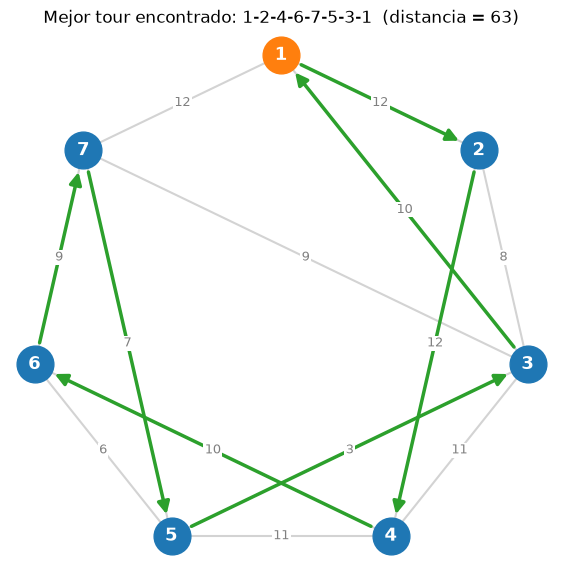

In [21]:
import math
import matplotlib.pyplot as plt

# El enunciado no da coordenadas, así que las ciudades se ubican en un círculo solo para dibujar.
ciudades_todas = [1, 2, 3, 4, 5, 6, 7]
pos = {c: (math.cos(math.pi / 2 - 2 * math.pi * k / 7), math.sin(math.pi / 2 - 2 * math.pi * k / 7))
       for k, c in enumerate(ciudades_todas)}

fig, ax = plt.subplots(figsize=(7, 7))

# Todas las carreteras en gris
for a, b, d in conexiones:
    (x1, y1), (x2, y2) = pos[a], pos[b]
    ax.plot([x1, x2], [y1, y2], color="lightgray", lw=1.5, zorder=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(d), color="gray", fontsize=9,
            ha="center", va="center", bbox=dict(fc="white", ec="none", pad=1))

# Mejor tour resaltado con flechas en el sentido del recorrido
for i in range(len(mejor_tour_r) - 1):
    a, b = mejor_tour_r[i], mejor_tour_r[i + 1]
    ax.annotate("", xy=pos[b], xytext=pos[a],
                arrowprops=dict(arrowstyle="-|>", color="tab:green", lw=2.5, mutation_scale=18,
                                shrinkA=16, shrinkB=16), zorder=2)

# Ciudades
for c, (x, y) in pos.items():
    ax.scatter(x, y, s=700, color="tab:orange" if c == 1 else "tab:blue", zorder=3)
    ax.text(x, y, str(c), color="white", fontsize=13, fontweight="bold", ha="center", va="center", zorder=4)

ax.set_title(f"Mejor tour encontrado: {formato_tour(mejor_tour_r)}  (distancia = {mejor_dist_r})")
ax.set_aspect("equal")
ax.axis("off")
plt.show()

#### ¿Por qué Hill Climbing puede detenerse en una solución local?
Hill Climbing solo mira los **vecinos inmediatos** del tour actual (los tours que se obtienen invirtiendo un tramo) y únicamente se mueve si alguno es **estrictamente mejor**. Cuando ningún vecino mejora, se detiene, aunque exista un recorrido mejor en otra parte.

Esto se ve en la Actividad 4: desde el tour `1-2-3-4-5-6-7-1` el algoritmo bajó de 69 a 65 y luego a 64, y se detuvo en `1-2-4-6-5-3-7-1`. Desde ahí, ningún cambio de un solo tramo reduce la distancia; el único vecino con 64 es la misma ruta recorrida al revés. Sin embargo, existe el tour `1-2-4-6-7-5-3-1` con distancia 63. Para llegar a él habría que pasar por tours peores o inválidos, y Hill Climbing nunca acepta empeorar.

Una forma de imaginarlo es un terreno con varios valles: el algoritmo es una pelota que rueda hacia abajo y se queda en el primer valle que encuentra, que no necesariamente es el más profundo. Los **reinicios aleatorios** sueltan la pelota desde distintos puntos: en los 100 reinicios se llegó a 63 en 34 ocasiones, a 64 en 15 y a 65 en 51, y el mejor resultado fue 63.

### Preguntas de análisis - Parte 1

**1. ¿Qué representa una solución, un vecino y la función objetivo en este problema?**

**Respuesta:** Una solucion representa un camino que cumple con el problema presentado, iniciar en 1, pasar por todas las ciudades y regresar a 1. Un vecino son soluciones que comparten la estructura principal que se hace un cambion en sus nodos para probar mas soluciones. Y la funcion objetivo es es la distancia total del tour, es el costo de esto y lo que queremos minimizar.

**2. ¿Por qué Hill Climbing puede detenerse aunque exista un recorrido mejor?**

**Respuesta:** Porque ya no logra encontrar mas variantes de vecinos inmediatos (un cambio de un tramo) y nunca acepta un tour peor.

**3. ¿Qué efecto tuvieron los reinicios aleatorios?**

**Respuesta:**  Los reinicios aleatorios nos permitieron explorar distintas soluciones que no partian de la solucion base, cada reinicio parte de otro punto y puede caer en un valle distinto.

---
# Parte 2. A\* - Ruta más corta en una red

### Enunciado
Un guardabosques debe desplazarse desde la entrada **O** hasta el punto **T**. Las estaciones O, A, B, C, D, E y T están conectadas por caminos de doble sentido. Se desea encontrar una ruta de costo mínimo utilizando A\*.

| Camino | Distancia |
|:---:|:---:|
| O-A | 2 |
| O-B | 5 |
| O-C | 4 |
| A-B | 2 |
| A-D | 7 |
| B-C | 1 |
| B-D | 4 |
| B-E | 3 |
| C-E | 4 |
| D-E | 1 |
| D-T | 5 |
| E-T | 7 |

**Coordenadas para calcular la heurística euclidiana:**

| Estación | x | y |
|:---:|:---:|:---:|
| O | 0.0 | 0.0 |
| A | 1.5 | 1.2 |
| B | 2.5 | 0.0 |
| C | 2.8 | -0.8 |
| D | 5.5 | 1.0 |
| E | 5.2 | 0.2 |
| T | 9.0 | 0.5 |

> **Recordatorio**
> A\* selecciona el nodo con menor $f(n) = g(n) + h(n)$.
> - $g(n)$: costo acumulado desde el origen.
> - $h(n)$: estimación del costo restante.
> - $f(n)$: costo total estimado.

### Datos de entrada
El grafo se guarda como lista de adyacencia: para cada estación, un diccionario con sus vecinos y la distancia. Como los caminos son de doble sentido, cada camino se agrega en ambas direcciones.

In [22]:
# ===== ENTRADAS: red de estaciones =====
# Cada tupla es (estación_a, estación_b, distancia). Los caminos son de doble sentido.
caminos = [
    ("O", "A", 2), ("O", "B", 5), ("O", "C", 4),
    ("A", "B", 2), ("A", "D", 7),
    ("B", "C", 1), ("B", "D", 4), ("B", "E", 3),
    ("C", "E", 4),
    ("D", "E", 1), ("D", "T", 5),
    ("E", "T", 7),
]

# Grafo como lista de adyacencia: grafo[nodo] = {vecino: distancia}
grafo = {}
for a, b, d in caminos:
    grafo.setdefault(a, {})[b] = d
    grafo.setdefault(b, {})[a] = d

# Coordenadas (x, y) de cada estación, usadas para la heurística
coordenadas = {
    "O": (0.0, 0.0), "A": (1.5, 1.2), "B": (2.5, 0.0), "C": (2.8, -0.8),
    "D": (5.5, 1.0), "E": (5.2, 0.2), "T": (9.0, 0.5),
}

for nodo in sorted(grafo):
    print(f"{nodo}: {grafo[nodo]}")

A: {'O': 2, 'B': 2, 'D': 7}
B: {'O': 5, 'A': 2, 'C': 1, 'D': 4, 'E': 3}
C: {'O': 4, 'B': 1, 'E': 4}
D: {'A': 7, 'B': 4, 'E': 1, 'T': 5}
E: {'B': 3, 'C': 4, 'D': 1, 'T': 7}
O: {'A': 2, 'B': 5, 'C': 4}
T: {'D': 5, 'E': 7}


### Actividad 7
Implemente una función `heuristica(nodo, meta, coordenadas)` usando distancia euclidiana.

In [23]:
import math

def heuristica(nodo, meta, coordenadas):
    """
    Entrada: nodo actual, nodo meta y diccionario de coordenadas.
    Proceso: calcula la distancia euclidiana (línea recta) entre ambos puntos.
    Resultado: h(n), una estimación del costo que falta para llegar a la meta.
    """
    x1, y1 = coordenadas[nodo]
    x2, y2 = coordenadas[meta]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


# ===== h(n) de cada estación hacia T =====
print(f"{'Estación':<10}{'Coordenadas':<15}{'h(n) hacia T':>13}")
print("-" * 38)
for nodo in coordenadas:
    print(f"{nodo:<10}{str(coordenadas[nodo]):<15}{heuristica(nodo, 'T', coordenadas):>13.3f}")

Estación  Coordenadas     h(n) hacia T
--------------------------------------
O         (0.0, 0.0)             9.014
A         (1.5, 1.2)             7.533
B         (2.5, 0.0)             6.519
C         (2.8, -0.8)            6.335
D         (5.5, 1.0)             3.536
E         (5.2, 0.2)             3.812
T         (9.0, 0.5)             0.000


### Actividad 8
Implemente A\* utilizando `heapq`. No utilizar networkx para resolver la búsqueda.

La lista abierta es un heap con entradas `(f, nodo, g)`. Cuando se encuentra un camino más barato a un nodo se agrega una nueva entrada; las entradas viejas se ignoran al sacarlas del heap.

In [24]:
import heapq

def a_estrella(grafo, coordenadas, inicio, meta, h=heuristica, mostrar=True):
    """
    Entrada: grafo, coordenadas, nodo inicio, nodo meta y la función heurística h
             (por defecto la euclidiana; se puede cambiar, por ejemplo, por h(n) = 0).
    Proceso: mantiene una lista abierta (heap) ordenada por f(n) = g(n) + h(n). En cada
             iteración expande el nodo de menor f y actualiza a sus vecinos si encuentra
             un camino más barato hacia ellos. Termina cuando expande la meta.
    Resultado: (ruta, costo total, número de nodos expandidos).
    """
    g = {inicio: 0}                      # mejor costo conocido desde el inicio
    padre = {inicio: None}               # para reconstruir la ruta
    cerrados = set()                     # nodos ya expandidos
    h0 = h(inicio, meta, coordenadas)
    abierta = [(h0, inicio, 0)]          # entradas (f, nodo, g)
    iteracion = 0

    if mostrar:
        print(f"{'Iter':<6}{'Expandido':<11}{'g(n)':>6}{'h(n)':>8}{'f(n)':>8}   Lista abierta [nodo(f)]")
        print("-" * 85)

    while abierta:
        f_n, nodo, g_n = heapq.heappop(abierta)
        if nodo in cerrados or g_n > g[nodo]:
            continue                     # entrada vieja: ya había un camino mejor
        iteracion += 1
        cerrados.add(nodo)

        if nodo != meta:
            for vecino, costo in grafo[nodo].items():
                if vecino in cerrados:
                    continue
                g_nuevo = g_n + costo
                if g_nuevo < g.get(vecino, float("inf")):   # camino más barato encontrado
                    g[vecino] = g_nuevo
                    padre[vecino] = nodo
                    f_nuevo = g_nuevo + h(vecino, meta, coordenadas)
                    heapq.heappush(abierta, (f_nuevo, vecino, g_nuevo))

        if mostrar:
            vigentes = sorted((f, n) for f, n, gg in abierta if n not in cerrados and gg == g[n])
            texto = ", ".join(f"{n}({f:.2f})" for f, n in vigentes) or "vacía"
            print(f"{iteracion:<6}{nodo:<11}{g_n:>6}{f_n - g_n:>8.2f}{f_n:>8.2f}   {texto}")

        if nodo == meta:                 # la meta salió de la lista abierta: ruta óptima
            ruta = []
            while nodo is not None:
                ruta.append(nodo)
                nodo = padre[nodo]
            return ruta[::-1], g_n, iteracion

    return None, float("inf"), iteracion  # no existe ruta

### Actividad 9
En cada iteración muestre: nodo expandido, g(n), h(n), f(n) y contenido de la lista abierta.

In [25]:
# ===== Registro por iteración de A* de O a T =====
ruta_a, costo_a, expandidos_a = a_estrella(grafo, coordenadas, "O", "T", mostrar=True)

Iter  Expandido    g(n)    h(n)    f(n)   Lista abierta [nodo(f)]
-------------------------------------------------------------------------------------
1     O               0    9.01    9.01   A(9.53), C(10.33), B(11.52)
2     A               2    7.53    9.53   C(10.33), B(10.52), D(12.54)
3     C               4    6.33   10.33   B(10.52), E(11.81), D(12.54)
4     B               4    6.52   10.52   E(10.81), D(11.54)
5     E               7    3.81   10.81   D(11.54), T(14.00)
6     D               8    3.54   11.54   T(13.00)
7     T              13    0.00   13.00   vacía


### Actividad 10
Encuentre la ruta de O a T, muestre el camino final y su costo total.

In [26]:
# ===== Ruta final y costo total =====
print(f"Ruta encontrada: {' -> '.join(ruta_a)}\n")
print(f"{'Tramo':<8}{'Distancia':>10}")
print("-" * 18)
for i in range(len(ruta_a) - 1):
    a, b = ruta_a[i], ruta_a[i + 1]
    print(f"{f'{a}-{b}':<8}{grafo[a][b]:>10}")
print("-" * 18)
print(f"{'Total':<8}{costo_a:>10}")

Ruta encontrada: O -> A -> B -> D -> T

Tramo    Distancia
------------------
O-A              2
A-B              2
B-D              4
D-T              5
------------------
Total           13


### Actividad 11
Ejecute nuevamente el algoritmo utilizando h(n)=0. Compare el resultado con A\* y explique la relación con Dijkstra.

In [27]:
def heuristica_cero(nodo, meta, coordenadas):
    """Heurística nula: h(n) = 0 para todo nodo."""
    return 0

# ===== A* con h(n) = 0 =====
ruta_0, costo_0, expandidos_0 = a_estrella(grafo, coordenadas, "O", "T", h=heuristica_cero, mostrar=True)

# ===== Comparación =====
print(f"\n{'Variante':<24}{'Ruta':<22}{'Costo':>6}{'Nodos expandidos':>18}")
print("-" * 70)
print(f"{'A* (h euclidiana)':<24}{' -> '.join(ruta_a):<22}{costo_a:>6}{expandidos_a:>18}")
print(f"{'h(n) = 0 (Dijkstra)':<24}{' -> '.join(ruta_0):<22}{costo_0:>6}{expandidos_0:>18}")

Iter  Expandido    g(n)    h(n)    f(n)   Lista abierta [nodo(f)]
-------------------------------------------------------------------------------------
1     O               0    0.00    0.00   A(2.00), C(4.00), B(5.00)
2     A               2    0.00    2.00   B(4.00), C(4.00), D(9.00)
3     B               4    0.00    4.00   C(4.00), E(7.00), D(8.00)
4     C               4    0.00    4.00   E(7.00), D(8.00)
5     E               7    0.00    7.00   D(8.00), T(14.00)
6     D               8    0.00    8.00   T(13.00)
7     T              13    0.00   13.00   vacía

Variante                Ruta                   Costo  Nodos expandidos
----------------------------------------------------------------------
A* (h euclidiana)       O -> A -> B -> D -> T     13                 7
h(n) = 0 (Dijkstra)     O -> A -> B -> D -> T     13                 7


#### Relación con Dijkstra
Con $h(n) = 0$ la fórmula queda $f(n) = g(n)$: el algoritmo elige siempre el nodo con menor costo acumulado, sin ninguna estimación de lo que falta. Eso es exactamente el **algoritmo de Dijkstra**, que explora "en círculos" alrededor del origen en orden de costo, sin dirección preferida hacia la meta.

Ambas versiones encontraron la misma ruta óptima `O -> A -> B -> D -> T` con costo 13. Esto es de esperarse porque la heurística euclidiana nunca sobreestima el costo real (una línea recta es el camino más corto posible), por lo que A\* también garantiza el óptimo.

En esta red ambas versiones expandieron 7 nodos, porque la red es pequeña y T está al extremo, así que casi todo queda "en el camino". Aun así se nota la diferencia en el **orden**: A\* expandió C antes que B porque C está más cerca de T, mientras que con $h(n) = 0$ se expandió B primero solo por orden alfabético en el empate de g = 4. En redes grandes, la heurística evita expandir nodos que se alejan de la meta.

### Actividad 12
Grafique la red con matplotlib y resalte la ruta encontrada.

Las estaciones se ubican según sus coordenadas. La ruta encontrada se marca en verde, el origen y la meta en naranja.

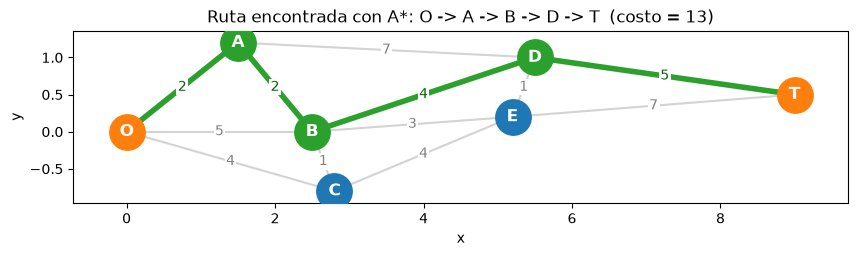

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
tramos_ruta = {frozenset((ruta_a[i], ruta_a[i + 1])) for i in range(len(ruta_a) - 1)}

# Caminos: en verde los de la ruta encontrada, en gris el resto
for a, b, d in caminos:
    (x1, y1), (x2, y2) = coordenadas[a], coordenadas[b]
    en_ruta = frozenset((a, b)) in tramos_ruta
    ax.plot([x1, x2], [y1, y2], color="tab:green" if en_ruta else "lightgray",
            lw=4 if en_ruta else 1.5, zorder=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(d), fontsize=10, ha="center", va="center",
            color="darkgreen" if en_ruta else "gray", bbox=dict(fc="white", ec="none", pad=1))

# Estaciones
for nodo, (x, y) in coordenadas.items():
    color = "tab:orange" if nodo in ("O", "T") else ("tab:green" if nodo in ruta_a else "tab:blue")
    ax.scatter(x, y, s=650, color=color, zorder=3)
    ax.text(x, y, nodo, color="white", fontsize=12, fontweight="bold", ha="center", va="center", zorder=4)

ax.set_title(f"Ruta encontrada con A*: {' -> '.join(ruta_a)}  (costo = {costo_a})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.margins(0.08)
plt.show()

### Preguntas de análisis - Parte 2

**1. ¿Qué información aporta g(n)? ¿Qué información aporta h(n)?**

**Respuesta:** g(n) representa el coste total acumulado que lelvas de ir recorriendo los diferenters nodos, y h(n) es la heuristica que es una pieza que nos ayuda a darnos una estimacion del costo de n hasta llegar a la meta.

**2. ¿Por qué una heurística útil puede reducir la cantidad de nodos explorados?**

**Respuesta:**  Porque la heurística le da dirección a la búsqueda. A* siempre expande el nodo con menor f(n) = g(n) + h(n), y h(n) estima cuánto falta para llegar a la meta. Así, los nodos que están más cerca de T obtienen un f(n) más bajo y se exploran primero. Los que se alejan de la meta obtienen un f(n) alto, quedan al fondo de la lista abierta y muchas veces nunca se llegan a expandir, porque la meta se alcanza antes.

**3. ¿Qué ocurre conceptualmente cuando h(n)=0?**

**Respuesta:**  Cuando esto pasa simplemente se vuelve djikstra, como no tiene estimacion de futuro recorre todo.

---
# Parte 3. Flujo Máximo y Costo Mínimo - Distribución de suministros

### Enunciado
Un centro de distribución **S** debe enviar suministros hacia un centro de atención **T**. Los nodos A, B, C, D y E representan centros intermedios. Cada conexión tiene una capacidad máxima y un costo por unidad transportada.

Las capacidades conservan la red del laboratorio base. Para incorporar el tema de Costo Mínimo, en esta versión se agregan costos unitarios didácticos a cada conexión.

| Tramo | Capacidad | Costo/unidad |
|:---:|:---:|:---:|
| S → A | 5 | 2 |
| S → B | 7 | 1 |
| S → C | 4 | 3 |
| A → B | 1 | 1 |
| A → D | 3 | 2 |
| B → C | 2 | 1 |
| B → D | 4 | 3 |
| B → E | 5 | 2 |
| C → E | 4 | 1 |
| D → T | 9 | 2 |
| E → D | 1 | 1 |
| E → T | 6 | 3 |

### Datos de entrada
Cada tramo se guarda con su capacidad y su costo por unidad en dos diccionarios con llave `(origen, destino)`. A diferencia de la Parte 2, las aristas son **dirigidas**: solo se puede enviar flujo en el sentido indicado.

In [29]:
# ===== ENTRADAS: red de distribución =====
# Cada tupla es (origen, destino, capacidad, costo por unidad). Las aristas son dirigidas.
tramos = [
    ("S", "A", 5, 2), ("S", "B", 7, 1), ("S", "C", 4, 3),
    ("A", "B", 1, 1), ("A", "D", 3, 2),
    ("B", "C", 2, 1), ("B", "D", 4, 3), ("B", "E", 5, 2),
    ("C", "E", 4, 1),
    ("D", "T", 9, 2),
    ("E", "D", 1, 1), ("E", "T", 6, 3),
]

capacidades = {(u, v): cap for u, v, cap, costo in tramos}
costos = {(u, v): costo for u, v, cap, costo in tramos}
FUENTE, DESTINO = "S", "T"

print(f"Tramos: {len(tramos)} | Fuente: {FUENTE} | Destino: {DESTINO}")
print(f"Capacidad total que sale de S: {sum(c for (u, v), c in capacidades.items() if u == FUENTE)}")
print(f"Capacidad total que llega a T: {sum(c for (u, v), c in capacidades.items() if v == DESTINO)}")

Tramos: 12 | Fuente: S | Destino: T
Capacidad total que sale de S: 16
Capacidad total que llega a T: 15


## Parte A - Flujo Máximo

### Actividad 13
Construya la red residual incluyendo aristas de regreso con capacidad inicial 0.

In [30]:
def construir_residual(capacidades):
    """
    Entrada: diccionario capacidades[(u, v)] = capacidad.
    Proceso: por cada arista u->v agrega su capacidad hacia adelante y una arista de
             regreso v->u con capacidad inicial 0.
    Resultado: red residual como diccionario residual[u][v] = capacidad disponible.
    """
    residual = {}
    for (u, v), cap in capacidades.items():
        residual.setdefault(u, {})
        residual.setdefault(v, {})
        residual[u][v] = residual[u].get(v, 0) + cap
        residual[v].setdefault(u, 0)     # arista de regreso
    return residual


# ===== Red residual inicial =====
residual_inicial = construir_residual(capacidades)
print(f"{'Arista':<10}{'Tipo':<12}{'Capacidad residual':>19}")
print("-" * 41)
for u in sorted(residual_inicial):
    for v in sorted(residual_inicial[u]):
        tipo = "original" if (u, v) in capacidades else "regreso"
        print(f"{f'{u} -> {v}':<10}{tipo:<12}{residual_inicial[u][v]:>19}")

Arista    Tipo         Capacidad residual
-----------------------------------------
A -> B    original                      1
A -> D    original                      3
A -> S    regreso                       0
B -> A    regreso                       0
B -> C    original                      2
B -> D    original                      4
B -> E    original                      5
B -> S    regreso                       0
C -> B    regreso                       0
C -> E    original                      4
C -> S    regreso                       0
D -> A    regreso                       0
D -> B    regreso                       0
D -> E    regreso                       0
D -> T    original                      9
E -> B    regreso                       0
E -> C    regreso                       0
E -> D    original                      1
E -> T    original                      6
S -> A    original                      5
S -> B    original                      7
S -> C    original                

### Actividad 14
Implemente Edmonds-Karp: utilice BFS para buscar caminos aumentantes desde S hasta T.

In [31]:
from collections import deque

def bfs_camino(residual, fuente, destino):
    """
    Entrada: red residual, fuente y destino.
    Proceso: búsqueda en anchura (BFS) usando solo aristas con capacidad residual > 0.
    Resultado: lista de nodos del camino aumentante más corto (en número de aristas), o None.
    """
    padre = {fuente: None}
    cola = deque([fuente])
    while cola:
        u = cola.popleft()
        for v in sorted(residual[u]):
            if v not in padre and residual[u][v] > 0:
                padre[v] = u
                if v == destino:         # se llegó al destino: reconstruir el camino
                    camino = [v]
                    while padre[camino[-1]] is not None:
                        camino.append(padre[camino[-1]])
                    return camino[::-1]
                cola.append(v)
    return None


def flujos_por_tramo(capacidades, residual):
    """Flujo en cada tramo original = capacidad original - capacidad residual restante."""
    return {(u, v): cap - residual[u][v] for (u, v), cap in capacidades.items()}


def edmonds_karp(capacidades, fuente, destino, mostrar=True):
    """
    Entrada: capacidades de cada tramo, fuente y destino.
    Proceso: mientras BFS encuentre un camino aumentante en la red residual, envía por él
             el cuello de botella, restándolo hacia adelante y sumándolo a las aristas de regreso.
    Resultado: (flujo máximo, flujo por tramo, red residual final).
    """
    residual = construir_residual(capacidades)
    flujo_total = 0
    iteracion = 0
    if mostrar:
        print(f"{'Iter':<6}{'Camino aumentante':<22}{'Cuello de botella':>18}{'Flujo enviado':>15}{'Flujo acumulado':>17}")
        print("-" * 78)

    while True:
        camino = bfs_camino(residual, fuente, destino)
        if camino is None:
            break
        iteracion += 1
        cuello = min(residual[camino[i]][camino[i + 1]] for i in range(len(camino) - 1))
        for i in range(len(camino) - 1):
            u, v = camino[i], camino[i + 1]
            residual[u][v] -= cuello     # se usa capacidad hacia adelante
            residual[v][u] += cuello     # se habilita la posibilidad de devolver ese flujo
        flujo_total += cuello
        if mostrar:
            print(f"{iteracion:<6}{' -> '.join(camino):<22}{cuello:>18}{cuello:>15}{flujo_total:>17}")

    if mostrar:
        print("-" * 78)
        print("No existen más caminos aumentantes de S a T.")
    return flujo_total, flujos_por_tramo(capacidades, residual), residual

### Actividad 15
En cada iteración muestre: camino aumentante, cuello de botella, flujo enviado y flujo acumulado.

In [32]:
# ===== Registro por iteración de Edmonds-Karp =====
flujo_max, flujos_ek, residual_final = edmonds_karp(capacidades, FUENTE, DESTINO, mostrar=True)

Iter  Camino aumentante      Cuello de botella  Flujo enviado  Flujo acumulado
------------------------------------------------------------------------------
1     S -> A -> D -> T                       3              3                3
2     S -> B -> D -> T                       4              4                7
3     S -> B -> E -> T                       3              3               10
4     S -> C -> E -> T                       3              3               13
5     S -> C -> E -> D -> T                  1              1               14
------------------------------------------------------------------------------
No existen más caminos aumentantes de S a T.


### Actividad 16
Al finalizar, muestre el flujo máximo y el flujo utilizado en cada tramo.

In [33]:
# ===== Flujo máximo y flujo utilizado en cada tramo =====
print(f"FLUJO MÁXIMO de {FUENTE} a {DESTINO}: {flujo_max}\n")
print(f"{'Tramo':<10}{'Flujo':>7}{'Capacidad':>11}{'Uso':>8}")
print("-" * 36)
for (u, v), cap in capacidades.items():
    f = flujos_ek[(u, v)]
    marca = "  <- saturado" if f == cap else ""
    print(f"{f'{u} -> {v}':<10}{f:>7}{cap:>11}{f / cap:>8.0%}{marca}")

FLUJO MÁXIMO de S a T: 14

Tramo       Flujo  Capacidad     Uso
------------------------------------
S -> A          3          5     60%
S -> B          7          7    100%  <- saturado
S -> C          4          4    100%  <- saturado
A -> B          0          1      0%
A -> D          3          3    100%  <- saturado
B -> C          0          2      0%
B -> D          4          4    100%  <- saturado
B -> E          3          5     60%
C -> E          4          4    100%  <- saturado
D -> T          8          9     89%
E -> D          1          1    100%  <- saturado
E -> T          6          6    100%  <- saturado


### Actividad 17
Verifique por código que ningún tramo exceda su capacidad y que en cada nodo intermedio el flujo que entra sea igual al flujo que sale.

In [34]:
def verificar_flujo(capacidades, flujos, fuente, destino):
    """
    Entrada: capacidades, flujo de cada tramo, fuente y destino.
    Proceso: revisa (1) que 0 <= flujo <= capacidad en cada tramo y (2) que en cada nodo
             intermedio el flujo que entra sea igual al flujo que sale.
    Resultado: True si se cumplen ambas condiciones.
    """
    ok = True
    print("1) Restricción de capacidad")
    for (u, v), cap in capacidades.items():
        cumple = 0 <= flujos[(u, v)] <= cap
        ok &= cumple
        if not cumple:
            print(f"   ERROR en {u} -> {v}: flujo {flujos[(u, v)]} fuera de [0, {cap}]")
    print("   Ningún tramo excede su capacidad." if ok else "   Hay tramos que exceden su capacidad.")

    print("\n2) Conservación de flujo en nodos intermedios")
    nodos = {n for arista in capacidades for n in arista} - {fuente, destino}
    print(f"   {'Nodo':<6}{'Entra':>7}{'Sale':>7}   Estado")
    for n in sorted(nodos):
        entra = sum(f for (u, v), f in flujos.items() if v == n)
        sale = sum(f for (u, v), f in flujos.items() if u == n)
        ok &= entra == sale
        print(f"   {n:<6}{entra:>7}{sale:>7}   {'OK' if entra == sale else 'ERROR'}")

    sale_fuente = sum(f for (u, v), f in flujos.items() if u == fuente)
    llega_destino = sum(f for (u, v), f in flujos.items() if v == destino)
    print(f"\n   Sale de {fuente}: {sale_fuente} | Llega a {destino}: {llega_destino}")
    print(f"\nResultado de la verificación: {'CORRECTO' if ok else 'INCORRECTO'}")
    return ok


verificar_flujo(capacidades, flujos_ek, FUENTE, DESTINO)

1) Restricción de capacidad
   Ningún tramo excede su capacidad.

2) Conservación de flujo en nodos intermedios
   Nodo    Entra   Sale   Estado
   A           3      3   OK
   B           7      7   OK
   C           4      4   OK
   D           8      8   OK
   E           7      7   OK

   Sale de S: 14 | Llega a T: 14

Resultado de la verificación: CORRECTO


True

## Parte B - Costo Mínimo
Ahora se utiliza la misma red, pero considerando también el costo por unidad. El objetivo es enviar el flujo máximo obtenido en la Parte A con el menor costo total posible.

### Actividad 18
Represente para cada arista su capacidad, costo y flujo actual.

In [35]:
# ===== Representación de cada arista: capacidad, costo y flujo actual =====
aristas = {(u, v): {"capacidad": cap, "costo": costo, "flujo": 0} for u, v, cap, costo in tramos}

print(f"{'Arista':<10}{'Capacidad':>10}{'Costo/u':>9}{'Flujo actual':>14}")
print("-" * 43)
for (u, v), datos in aristas.items():
    print(f"{f'{u} -> {v}':<10}{datos['capacidad']:>10}{datos['costo']:>9}{datos['flujo']:>14}")

Arista     Capacidad  Costo/u  Flujo actual
-------------------------------------------
S -> A             5        2             0
S -> B             7        1             0
S -> C             4        3             0
A -> B             1        1             0
A -> D             3        2             0
B -> C             2        1             0
B -> D             4        3             0
B -> E             5        2             0
C -> E             4        1             0
D -> T             9        2             0
E -> D             1        1             0
E -> T             6        3             0


### Actividad 19
Implemente una red residual de costos: una arista de regreso debe permitir corregir decisiones anteriores y utilizar el costo opuesto de la arista original.

In [36]:
def construir_residual_costos(capacidades, costos):
    """
    Entrada: capacidades y costos por unidad de cada tramo.
    Proceso: arista original u->v con su capacidad y su costo; arista de regreso v->u con
             capacidad 0 y costo opuesto (-costo), porque devolver flujo "reembolsa" su costo.
    Resultado: (residual[u][v] = capacidad disponible, costo_res[u][v] = costo por unidad).
    """
    residual = construir_residual(capacidades)
    costo_res = {u: {} for u in residual}
    for (u, v), c in costos.items():
        costo_res[u][v] = c
        costo_res[v][u] = -c
    return residual, costo_res


# ===== Red residual de costos inicial =====
residual_c, costo_res = construir_residual_costos(capacidades, costos)
print(f"{'Arista':<10}{'Tipo':<12}{'Capacidad residual':>19}{'Costo':>8}")
print("-" * 49)
for u in sorted(residual_c):
    for v in sorted(residual_c[u]):
        tipo = "original" if (u, v) in capacidades else "regreso"
        print(f"{f'{u} -> {v}':<10}{tipo:<12}{residual_c[u][v]:>19}{costo_res[u][v]:>8}")

Arista    Tipo         Capacidad residual   Costo
-------------------------------------------------
A -> B    original                      1       1
A -> D    original                      3       2
A -> S    regreso                       0      -2
B -> A    regreso                       0      -1
B -> C    original                      2       1
B -> D    original                      4       3
B -> E    original                      5       2
B -> S    regreso                       0      -1
C -> B    regreso                       0      -1
C -> E    original                      4       1
C -> S    regreso                       0      -3
D -> A    regreso                       0      -2
D -> B    regreso                       0      -3
D -> E    regreso                       0      -1
D -> T    original                      9       2
E -> B    regreso                       0      -2
E -> C    regreso                       0      -1
E -> D    original                      1       1


### Actividad 20
Busque repetidamente un camino S-T de menor costo dentro de la red residual que aún tenga capacidad disponible.

Como las aristas de regreso tienen costos negativos, el camino de menor costo se busca con **Bellman-Ford** (Dijkstra no funciona correctamente con costos negativos).

In [37]:
def camino_menor_costo(residual, costos, fuente, destino):
    """
    Entrada: red residual (capacidades), costos residuales, fuente y destino.
    Proceso: Bellman-Ford sobre las aristas con capacidad residual > 0. Se usa Bellman-Ford
             y no Dijkstra porque las aristas de regreso tienen costos negativos.
    Resultado: (camino de menor costo, costo por unidad del camino), o (None, inf).
    """
    dist = {n: float("inf") for n in residual}
    padre = {n: None for n in residual}
    dist[fuente] = 0
    for _ in range(len(residual) - 1):           # relajar todas las aristas |V|-1 veces
        hubo_cambio = False
        for u in sorted(residual):
            if dist[u] == float("inf"):
                continue
            for v in sorted(residual[u]):
                if residual[u][v] > 0 and dist[u] + costos[u][v] < dist[v]:
                    dist[v] = dist[u] + costos[u][v]
                    padre[v] = u
                    hubo_cambio = True
        if not hubo_cambio:
            break
    if dist[destino] == float("inf"):
        return None, float("inf")
    camino = [destino]
    while camino[-1] != fuente:
        camino.append(padre[camino[-1]])
    return camino[::-1], dist[destino]


# ===== Prueba: camino más barato en la red inicial =====
camino, c = camino_menor_costo(residual_c, costo_res, FUENTE, DESTINO)
print(f"Camino de menor costo inicial: {' -> '.join(camino)} con costo {c} por unidad")

Camino de menor costo inicial: S -> A -> D -> T con costo 6 por unidad


### Actividades 21 y 22
- **21.** Envíe por el camino tanto flujo como permitan el cuello de botella y el flujo restante por asignar.
- **22.** Actualice capacidades residuales, aristas de regreso, flujo acumulado y costo acumulado.

In [38]:
def flujo_costo_minimo(capacidades, costos, fuente, destino, flujo_objetivo, mostrar=True):
    """
    Entrada: capacidades, costos, fuente, destino y cantidad de flujo a enviar.
    Proceso: mientras falte flujo por enviar, busca el camino S-T de menor costo en la red
             residual, envía min(cuello de botella, flujo restante), y actualiza capacidades
             residuales, aristas de regreso, flujo acumulado y costo acumulado.
    Resultado: (flujo enviado, costo total, flujo por tramo).
    """
    residual, costo_res = construir_residual_costos(capacidades, costos)
    flujo_enviado, costo_total, iteracion = 0, 0, 0
    if mostrar:
        print(f"{'Iter':<6}{'Ruta elegida':<24}{'Costo/u':>8}{'Cuello':>8}{'Enviado':>9}"
              f"{'Flujo acum.':>13}{'Costo acum.':>13}")
        print("-" * 81)

    while flujo_enviado < flujo_objetivo:
        camino, costo_u = camino_menor_costo(residual, costo_res, fuente, destino)
        if camino is None:
            print("No hay más caminos con capacidad: no se alcanzó el flujo objetivo.")
            break
        iteracion += 1
        cuello = min(residual[camino[i]][camino[i + 1]] for i in range(len(camino) - 1))
        enviar = min(cuello, flujo_objetivo - flujo_enviado)
        for i in range(len(camino) - 1):
            u, v = camino[i], camino[i + 1]
            residual[u][v] -= enviar     # se usa capacidad hacia adelante
            residual[v][u] += enviar     # arista de regreso para poder corregir después
        flujo_enviado += enviar
        costo_total += enviar * costo_u
        if mostrar:
            print(f"{iteracion:<6}{' -> '.join(camino):<24}{costo_u:>8}{cuello:>8}{enviar:>9}"
                  f"{flujo_enviado:>13}{costo_total:>13}")

    return flujo_enviado, costo_total, flujos_por_tramo(capacidades, residual)

### Actividad 23
Muestre por iteración: ruta elegida, costo por unidad de la ruta, cuello de botella, flujo enviado y costo acumulado.

In [39]:
# ===== Registro por iteración: enviar el flujo máximo de la Parte A al menor costo =====
print(f"Flujo objetivo (flujo máximo de la Parte A): {flujo_max}\n")
flujo_cm, costo_cm, flujos_cm = flujo_costo_minimo(capacidades, costos, FUENTE, DESTINO, flujo_max, mostrar=True)

Flujo objetivo (flujo máximo de la Parte A): 14

Iter  Ruta elegida             Costo/u  Cuello  Enviado  Flujo acum.  Costo acum.
---------------------------------------------------------------------------------
1     S -> A -> D -> T               6       3        3            3           18
2     S -> B -> D -> T               6       4        4            7           42
3     S -> B -> E -> T               6       3        3           10           60
4     S -> C -> E -> T               7       3        3           13           81
5     S -> C -> E -> D -> T          7       1        1           14           88


### Actividad 24
Reporte al final: flujo enviado, costo total mínimo y flujo utilizado en cada tramo.

Al final se compara el costo de la distribución obtenida con Edmonds-Karp, la de costo mínimo y otra distribución válida que también envía 14 unidades.

In [40]:
def costo_distribucion(flujos, costos):
    """Costo total de una distribución: suma de flujo * costo por unidad en cada tramo."""
    return sum(flujos[a] * costos[a] for a in flujos)

# ===== Reporte final =====
print(f"Flujo enviado:      {flujo_cm}")
print(f"Costo total mínimo: {costo_cm}\n")

print(f"{'Tramo':<10}{'Flujo':>7}{'Capacidad':>11}{'Costo/u':>9}{'Costo tramo':>13}")
print("-" * 50)
for (u, v), cap in capacidades.items():
    f = flujos_cm[(u, v)]
    print(f"{f'{u} -> {v}':<10}{f:>7}{cap:>11}{costos[(u, v)]:>9}{f * costos[(u, v)]:>13}")
print("-" * 50)
print(f"{'Total':<37}{costo_distribucion(flujos_cm, costos):>13}\n")

verificar_flujo(capacidades, flujos_cm, FUENTE, DESTINO)

# Comparación con la distribución de Edmonds-Karp (mismo flujo, sin considerar costos)
print(f"\n{'Distribución':<28}{'Flujo':>7}{'Costo total':>13}")
print("-" * 48)
print(f"{'Edmonds-Karp (Parte A)':<28}{flujo_max:>7}{costo_distribucion(flujos_ek, costos):>13}")
print(f"{'Costo mínimo (Parte B)':<28}{flujo_cm:>7}{costo_cm:>13}")

# Otra distribución válida que también envía 14 unidades (usa A -> B en lugar de S -> B completo)
flujos_alt = dict(flujos_cm)
flujos_alt.update({("S", "A"): 4, ("A", "B"): 1, ("S", "B"): 6})
print(f"{'Alternativa (S->A->B)':<28}{sum(f for (u, v), f in flujos_alt.items() if u == FUENTE):>7}"
      f"{costo_distribucion(flujos_alt, costos):>13}")

Flujo enviado:      14
Costo total mínimo: 88

Tramo       Flujo  Capacidad  Costo/u  Costo tramo
--------------------------------------------------
S -> A          3          5        2            6
S -> B          7          7        1            7
S -> C          4          4        3           12
A -> B          0          1        1            0
A -> D          3          3        2            6
B -> C          0          2        1            0
B -> D          4          4        3           12
B -> E          3          5        2            6
C -> E          4          4        1            4
D -> T          8          9        2           16
E -> D          1          1        1            1
E -> T          6          6        3           18
--------------------------------------------------
Total                                           88

1) Restricción de capacidad
   Ningún tramo excede su capacidad.

2) Conservación de flujo en nodos intermedios
   Nodo    Entra   Sale 

### Preguntas de análisis - Parte 3

**1. ¿Por qué maximizar el flujo y minimizar el costo son objetivos distintos?**

**Respuesta:** Cada uno usa información diferente y responde una pregunta diferente.

Flujo máximo solo mira las capacidades. no mira si una ruta es cara o barata: solo quiere meter la mayor cantidad posible.
Costo mínimo parte de una cantidad fija (las 14 unidades) y decide cómo repartirlas para pagar lo menos posible.

**2. ¿Puede haber dos distribuciones con el mismo flujo máximo pero costos diferentes? Explique.**

**Respuesta:** Sí. El flujo máximo solo dice cuántas unidades caben, no por dónde deben ir, y casi siempre hay varias rutas para llegar al mismo nodo. Por ejemplo, la distribución de costo mínimo envía 14 unidades con costo 88. Si una unidad se manda por S→A→B (costo 3) en vez de S→B (costo 1), se siguen enviando 14 unidades pero el costo sube a 90.

**3. ¿Para qué sirven las aristas de regreso en la red residual?**

**Respuesta:** Las aristas de regreso permiten corregir decisiones tomadas en iteraciones anteriores. Cuando se envía flujo por u→v, la arista v→u gana esa misma capacidad, lo que permite "devolver" ese flujo y redirigirlo por otra ruta si eso mejora el resultado. En costo mínimo tienen costo negativo, porque deshacer un envío recupera su costo. Sin ellas, los algoritmos podrían quedarse con una mala distribución inicial sin poder arreglarla.

**4. ¿Qué conexión parece actuar como cuello de botella en la red?**

**Respuesta:** El cuello de botella está en las conexiones que llegan a D y a T: A→D (3), B→D (4), E→D (1) y E→T (6), todas saturadas. Sus capacidades suman 14, exactamente el flujo máximo. Aunque D→T tiene capacidad 9, solo pasan 8 unidades, porque a D no pueden entrar más de 3 + 4 + 1 = 8. Por eso a T llegan 14 y no 15. La conexión más restrictiva es E→D, con capacidad 1: E recibe 7 unidades pero solo puede pasar 1 hacia D, y el resto tiene que ir por E→T, que también se llena. Si se aumentara la capacidad de E→D o de A→D, el flujo máximo podría crecer.

---
# Integración final
Los tres ejercicios utilizan estrategias diferentes para responder preguntas diferentes.

| Algoritmo | Pregunta principal | Información utilizada | Resultado |
|---|---|---|---|
| **Hill Climbing** | ¿Cómo mejoro la solución actual? | Vecinos del tour actual (inversión de un sub-recorrido) + función objetivo (distancia total del tour) | Mejor solución local encontrada. Desde 1-2-3-4-5-6-7-1 se estancó en un óptimo local de distancia 64; con 100 reinicios aleatorios se encontró el tour 1-2-4-6-7-5-3-1 con distancia 63 |
| **A\*** | ¿Cuál es una ruta de menor costo? | g(n) = costo real acumulado desde el origen + h(n) = distancia euclidiana estimada hasta la meta | Camino y costo: O → A → B → D → T con costo 13. Con h(n) = 0 (Dijkstra) se obtiene la misma ruta, pero sin orientación hacia la meta |
| **Flujo Máximo** | ¿Cuánto puedo transportar? | Capacidades de cada tramo + red residual con aristas de regreso, recorrida con BFS (Edmonds-Karp) | Flujo máximo de 14 unidades de S a T, limitado por los tramos que llegan a D y T (A→D, B→D, E→D y E→T) |
| **Costo Mínimo** | ¿Cómo transporto con menor costo? | Capacidad + flujo + costo por unidad, en una red residual con costos opuestos en las aristas de regreso (Bellman-Ford) | Distribución de las 14 unidades con costo total mínimo de 88, frente a otras distribuciones válidas con el mismo flujo que cuestan hasta 90 |

---
# Conclusión final

Esto diferentes algoritmos nos ayudan para diferentes ocaciones pero ambas son buenas en sus ambitos.

Hill Climbing mejora una solución paso a paso, moviéndose siempre al mejor vecino. Es simple y rápido, pero solo ve sus vecinos inmediatos y nunca acepta empeorar, por lo que puede quedarse en un óptimo local.

A* nos ayuda a encontrar la ruta mas corta de manera eficiente, dado a al heuristica que nos ayuda a ver y decidir por donde movernos a futuro hace que no recorramos todas las soluciones posibles, eso lo diferencia de soluciones como djikstra que es menos eficiente. 

Flujo máximo y costo mínimo resuelven dos preguntas en orden. Primero, Edmonds-Karp determina cuánto se puede transportar, y eso lo limitan las capacidades de la red y su cuello de botella. Después, el algoritmo de costo mínimo decide por dónde enviar esas 14 unidades para pagar lo menos posible